## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

BASE_DIR   = Path('..')
GOLD_DIR   = BASE_DIR / 'data' / 'gold'
FIG_DIR    = BASE_DIR / 'figures'
REPORT_DIR = BASE_DIR / 'reports'
FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY   = '#075020'
SECONDARY = '#8A7A2F'

sns.set_theme(style='whitegrid')
mpl.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

## Load data

In [2]:
train = pd.read_parquet(GOLD_DIR / 'train.parquet')
test  = pd.read_parquet(GOLD_DIR / 'test.parquet')
df    = pd.concat([train, test]).sort_values('date').reset_index(drop=True)
print(f'Total: {len(df)} matches | Train: {len(train)} | Test: {len(test)}')

Total: 312 matches | Train: 255 | Test: 57


## Tier classification

In [3]:
TIER1 = {'New Zealand', 'Australia', 'England', 'France', 'Ireland', 'Wales', 'Scotland', 'Argentina', 'Italy'}

for frame in [df, train, test]:
    frame['tier'] = frame['opponent'].apply(lambda x: 'Tier 1' if x in TIER1 else 'Tier 2+')

print('Tier distribution (full dataset):')
print(df['tier'].value_counts())

Tier distribution (full dataset):
tier
Tier 1    312
Name: count, dtype: int64


## Descriptive stats by tier

In [6]:
tier_stats = df.groupby('tier').agg(
    matches  = ('win', 'count'),
    wins     = ('win', 'sum'),
    win_rate = ('win', 'mean'),
).round(3)

print('=== Win Rate by Tier (1992-2022) ===')
print(tier_stats)
tier_stats.to_csv(REPORT_DIR / 'tier_stats.csv')

=== Win Rate by Tier (1992-2022) ===
        matches  wins  win_rate
tier                           
Tier 1      312   180     0.577


## Train model and predict on test set

In [7]:
features_num = ['home', 'rolling_form_3', 'rolling_form_5', 'rolling_margin_3', 'h2h_winrate', 'days_since_prev', 'elo_diff_pre']
features_cat = ['opponent', 'tournament']
target = 'win'

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_cat),
    ('num', 'passthrough', features_num),
])

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(C=1.0, max_iter=1000, random_state=42))
])

pipe.fit(train[features_num + features_cat], train[target].astype(int))

test = test.copy()
test['pred']      = pipe.predict(test[features_num + features_cat])
test['pred_prob'] = pipe.predict_proba(test[features_num + features_cat])[:, 1]

for frame in [df, train, test]:
    frame['tier'] = frame['opponent'].apply(
        lambda x: 'Tier 1' if x in TIER1 else 'Tier 2+'
    )
print(df['tier'].value_counts())

tier
Tier 1    312
Name: count, dtype: int64


## Performance by tier

In [8]:
results = []
for tier in ['Tier 1', 'Tier 2+', 'All']:
    subset = test if tier == 'All' else test[test['tier'] == tier]
    if len(subset) == 0:
        continue
    acc      = accuracy_score(subset[target].astype(int), subset['pred'])
    baseline = subset[target].mean()
    n        = len(subset)
    se       = np.sqrt(acc * (1 - acc) / n)
    ci_low   = max(0, acc - 1.96 * se)
    ci_high  = min(1, acc + 1.96 * se)
    try:
        auc = roc_auc_score(subset[target].astype(int), subset['pred_prob'])
    except Exception:
        auc = float('nan')
    results.append({
        'Tier': tier,
        'N': n,
        'Actual win rate': round(baseline, 3),
        'Accuracy': round(acc, 3),
        '95% CI': f'[{ci_low:.2f}, {ci_high:.2f}]',
        'ROC-AUC': round(auc, 3)
    })

results_df = pd.DataFrame(results)
print('=== Model Performance by Tier (Test Set 2017-2022) ===')
print(results_df.to_string(index=False))
results_df.to_csv(REPORT_DIR / 'tier_performance.csv', index=False)

=== Model Performance by Tier (Test Set 2017-2022) ===
  Tier  N  Actual win rate  Accuracy       95% CI  ROC-AUC
Tier 1 57            0.579     0.684 [0.56, 0.80]    0.763
   All 57            0.579     0.684 [0.56, 0.80]    0.763


## Figure: Win rate and accuracy by tier

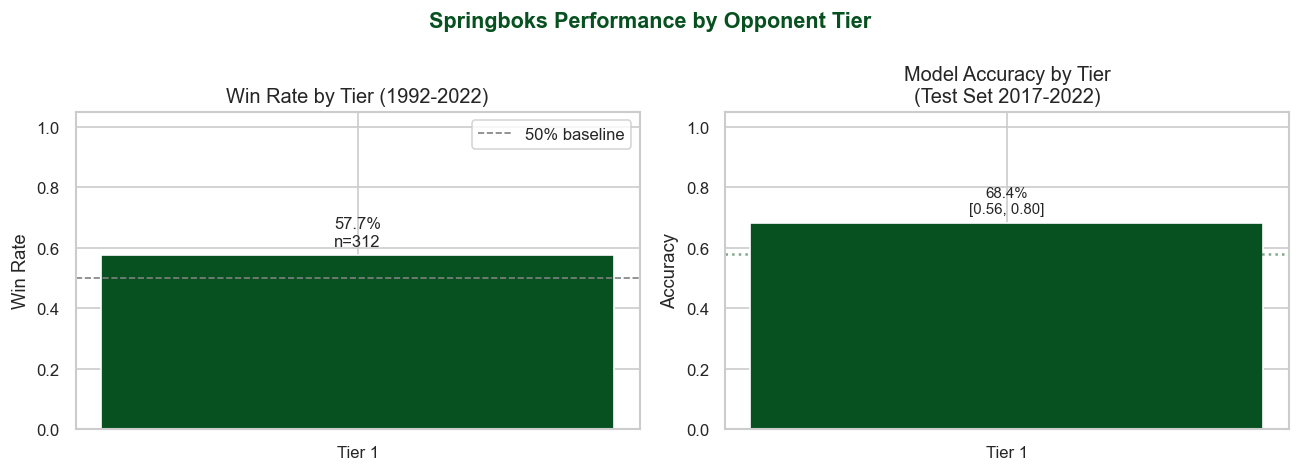

Saved: figures/tier_analysis.pdf


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Springboks Performance by Opponent Tier', fontsize=13, fontweight='bold', color=PRIMARY)

tier_plot = tier_stats.reset_index()
colors    = [PRIMARY if t == 'Tier 1' else SECONDARY for t in tier_plot['tier']]

axes[0].bar(tier_plot['tier'], tier_plot['win_rate'], color=colors, edgecolor='white', width=0.5)
axes[0].axhline(0.5, color='grey', linestyle='--', linewidth=1, label='50% baseline')
axes[0].set_title('Win Rate by Tier (1992-2022)')
axes[0].set_ylabel('Win Rate')
axes[0].set_ylim(0, 1.05)
axes[0].legend()
for i, row in tier_plot.iterrows():
    axes[0].text(i, row['win_rate'] + 0.03, f"{row['win_rate']:.1%}\nn={int(row['matches'])}", ha='center', fontsize=10)

tier_acc = results_df[results_df['Tier'] != 'All'].reset_index(drop=True)
colors2  = [PRIMARY if t == 'Tier 1' else SECONDARY for t in tier_acc['Tier']]
axes[1].bar(tier_acc['Tier'], tier_acc['Accuracy'], color=colors2, edgecolor='white', width=0.5)
for i, row in tier_acc.iterrows():
    axes[1].axhline(row['Actual win rate'], color=colors2[i], linestyle=':', linewidth=1.5, alpha=0.5)
axes[1].set_title('Model Accuracy by Tier\n(Test Set 2017-2022)')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
for i, row in tier_acc.iterrows():
    axes[1].text(i, row['Accuracy'] + 0.03, f"{row['Accuracy']:.1%}\n{row['95% CI']}", ha='center', fontsize=9)

plt.tight_layout()
fig.savefig(FIG_DIR / 'tier_analysis.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'tier_analysis.png', bbox_inches='tight')
plt.show()
print('Saved: figures/tier_analysis.pdf')

## WM 2027 Outlook

In [10]:
WM_OPPONENTS = ['New Zealand', 'Australia', 'England', 'France', 'Ireland', 'Argentina', 'Wales', 'Scotland']

wm_rows = []
for opp in WM_OPPONENTS:
    full   = df[df['opponent'] == opp]
    recent = df[(df['opponent'] == opp) & (df['date'].dt.year >= 2018)]
    if len(full) == 0:
        continue
    wm_rows.append({
        'Opponent': opp,
        'Total matches': len(full),
        'Overall win rate': round(full['win'].mean(), 3),
        'Recent win rate (2018-2022)': round(recent['win'].mean(), 3) if len(recent) > 0 else None,
        'Avg Elo diff': round(full['elo_diff_pre'].mean(), 1)
    })

wm_df = pd.DataFrame(wm_rows).sort_values('Overall win rate', ascending=True)
print('=== WM 2027 Outlook ===')
print(wm_df.to_string(index=False))
wm_df.to_csv(REPORT_DIR / 'wm2027_opponents.csv', index=False)

=== WM 2027 Outlook ===
   Opponent  Total matches  Overall win rate  Recent win rate (2018-2022)  Avg Elo diff
New Zealand             66             0.273                        0.375         -46.3
  Australia             64             0.422                        0.429          15.5
     France             26             0.577                        0.500          58.9
    England             36             0.583                        0.571          62.0
    Ireland             17             0.588                        0.000         100.4
      Wales             33             0.788                        0.571         147.0
  Argentina             34             0.882                        0.875         155.9
   Scotland             20             0.900                        1.000         123.2


## Figure: WM 2027 Outlook

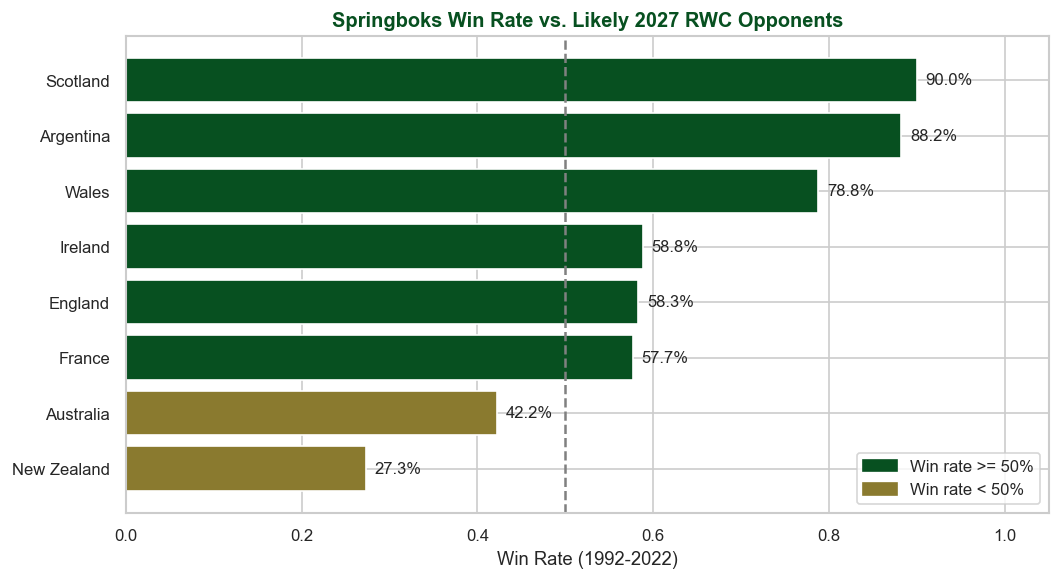

Saved: figures/wm2027_outlook.pdf
Done.


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

colors_wm = [PRIMARY if w >= 0.5 else SECONDARY for w in wm_df['Overall win rate']]
bars = ax.barh(wm_df['Opponent'], wm_df['Overall win rate'], color=colors_wm, edgecolor='white')
ax.axvline(0.5, color='grey', linestyle='--', linewidth=1.5)
ax.set_xlabel('Win Rate (1992-2022)')
ax.set_title('Springboks Win Rate vs. Likely 2027 RWC Opponents', fontsize=12, fontweight='bold', color=PRIMARY)

for bar, val in zip(bars, wm_df['Overall win rate']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2, f'{val:.1%}', va='center', fontsize=10)

green_patch = mpatches.Patch(color=PRIMARY,   label='Win rate >= 50%')
gold_patch  = mpatches.Patch(color=SECONDARY, label='Win rate < 50%')
ax.legend(handles=[green_patch, gold_patch])
ax.set_xlim(0, 1.05)

plt.tight_layout()
fig.savefig(FIG_DIR / 'wm2027_outlook.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'wm2027_outlook.png', bbox_inches='tight')
plt.show()
print('Saved: figures/wm2027_outlook.pdf')
print('Done.')